# Power Analysis


- Questions: Is the one way ANOVA here the same as what Morgan used?
- Should I separate the analysis by block?
- The sequence memory test? Other analyses?
- Are we adequetly powered?

In [64]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# statsmodels for power calculations
from statsmodels.stats.power import FTestAnovaPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Study Parameters

In [65]:
# ── Standard parameters ──────────────────────────────────────────────────────
ALPHA        = 0.05          # significance level
TARGET_POWER = 0.80          # conventional minimum power
# TODO: What is the typical effect size for this type of experiment?
# EFFECT_SIZE  = 0.40          # Cohen's f values: small 0.10, medium 0.25, large 0.40
EFFECT_SIZE = 0.50
N_GROUPS     = 3             # number of conditions

# TODO: How are these decided on?
N_PER_GROUP  = 50            # number of participants per condition   

## 2. Prospective Power Analysis — Minimum Required Sample Size

We first determine how many participants **per group** are needed to detect a medium effect with 80% power.

In [66]:
power_analysis = FTestAnovaPower()

n_required = power_analysis.solve_power(
    effect_size=EFFECT_SIZE,
    alpha=ALPHA,
    power=TARGET_POWER,
    k_groups=N_GROUPS
)

n_required_ceil = int(np.ceil(n_required))

print('─' * 50)
print(f'Minimum n per group : {n_required_ceil}')
print(f'Total N required    : {n_required_ceil * N_GROUPS}')
print('─' * 50)

──────────────────────────────────────────────────
Minimum n per group : 42
Total N required    : 126
──────────────────────────────────────────────────


## 3. Power Curve — Across a Range of Sample Sizes

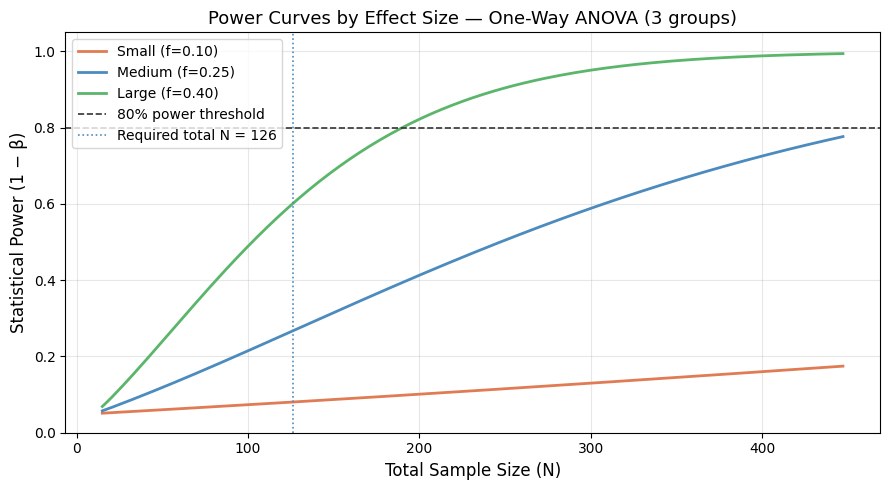

In [67]:
ns = np.arange(5, 150, 1)

power_values = [
    power_analysis.solve_power(
        effect_size=EFFECT_SIZE,
        alpha=ALPHA,
        nobs=n,
        k_groups=N_GROUPS
    )
    for n in ns
]

# ── Power curves for small / medium / large effects ───────────────────────────
effect_sizes = {'Small (f=0.10)': 0.10, 'Medium (f=0.25)': 0.25, 'Large (f=0.40)': 0.40}
power_curves = {
    label: [
        power_analysis.solve_power(effect_size=f, alpha=ALPHA, nobs=n, k_groups=N_GROUPS)
        for n in ns
    ]
    for label, f in effect_sizes.items()
}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e07b54', '#4c8bbe', '#5bb56b']

for (label, pv), color in zip(power_curves.items(), colors):
    ax.plot(ns * N_GROUPS, pv, label=label, color=color, lw=2)

ax.axhline(TARGET_POWER, ls='--', color='#333', lw=1.2, label='80% power threshold')
ax.axvline(n_required_ceil * N_GROUPS, ls=':', color='#4c8bbe', lw=1.2,
           label=f'Required total N = {n_required_ceil * N_GROUPS}')

ax.set_xlabel('Total Sample Size (N)', fontsize=12)
ax.set_ylabel('Statistical Power (1 − β)', fontsize=12)
ax.set_title('Power Curves by Effect Size — One-Way ANOVA (3 groups)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Read in Memory Test data / get MEANS / get SDs


In [68]:
import pandas as pd

INDIVIDUAL_MEMORY_TEST_DATA = pd.read_csv('./data/for-analysis/test_data.csv')

In [69]:
ANALYSIS_DATA = INDIVIDUAL_MEMORY_TEST_DATA[['condition', 'breakpoint', 'euclidean']]


In [70]:
ANALYSIS_DATA['condition'].unique()

<StringArray>
['Shipwrecked', 'Baseline', 'Safecracker']
Length: 3, dtype: str

In [71]:
# TODO: Do I want to separate by block?
CONDITION_MEANS = [
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Shipwrecked']['euclidean'].mean(),
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Safecracjer']['euclidean'].mean(),
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Baseline']['euclidean'].mean()
]
CONDITION_SDS   = [
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Shipwrecked']['euclidean'].std(),
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Safecracjer']['euclidean'].std(),
    ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Baseline']['euclidean'].std()
]

In [72]:
SHIPWRECKED = ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Shipwrecked']
SAFECRACKER = ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Safecracker']
BASELINE = ANALYSIS_DATA[ANALYSIS_DATA['condition'] == 'Baseline']

euclideans = ANALYSIS_DATA['euclidean']

## 5. One-Way ANOVA

In [73]:
F_stat, p_value = stats.f_oneway(SHIPWRECKED['euclidean'], SAFECRACKER['euclidean'], BASELINE['euclidean'])

# Compute observed Cohen's f
grand_mean = euclideans.mean()
group_means = np.array([SHIPWRECKED['euclidean'].mean(), SAFECRACKER['euclidean'].mean(), BASELINE['euclidean'].mean()])
sigma_m = np.sqrt(np.mean((group_means - grand_mean) ** 2))
sigma_e = np.sqrt(np.mean([np.var(g, ddof=1) for g in [SHIPWRECKED['euclidean'], SAFECRACKER['euclidean'], BASELINE['euclidean']]]))
cohens_f_obs = sigma_m / sigma_e

print('─' * 50)
print(f'F({N_GROUPS - 1}, {N_PER_GROUP * N_GROUPS - N_GROUPS}) = {F_stat:.3f}')
print(f'p-value         = {p_value:.4f}')
print(f"Observed Cohen's f = {cohens_f_obs:.3f}")
print('─' * 50)

if p_value > ALPHA:
    print('Result: Fail to reject H₀ (null result).')
else:
    print('Result: Reject H₀.')

──────────────────────────────────────────────────
F(2, 147) = 1.595
p-value         = 0.2031
Observed Cohen's f = 0.040
──────────────────────────────────────────────────
Result: Fail to reject H₀ (null result).


## 6. Retrospective Power at the Observed Effect Size

We now ask: *given the effect size we actually observed, how much power did we have?*

High retrospective power + null result = strong evidence **for** the null.

In [74]:
# Power at the planned (medium) effect size
power_planned = power_analysis.solve_power(
    effect_size=EFFECT_SIZE,
    alpha=ALPHA,
    nobs=N_PER_GROUP,
    k_groups=N_GROUPS
)

# Power at the observed effect size (if > 0)
power_observed = power_analysis.solve_power(
    effect_size=max(cohens_f_obs, 0.001),
    alpha=ALPHA,
    nobs=N_PER_GROUP,
    k_groups=N_GROUPS
)

print('─' * 55)
print(f"Power for medium effect (f=0.25)      : {power_planned:.3f}")
print(f"Power for observed effect (f={cohens_f_obs:.3f})   : {power_observed:.3f}")
print('─' * 55)
print()
if power_planned >= TARGET_POWER:
    print(f'✔ Study was well-powered ({power_planned:.1%}) to detect a medium effect.')
    print('  A null result therefore provides meaningful support for H₀.')
else:
    print(f'✘ Study was underpowered ({power_planned:.1%}). Null result is inconclusive.')

───────────────────────────────────────────────────────
Power for medium effect (f=0.25)      : 0.875
Power for observed effect (f=0.040)   : 0.056
───────────────────────────────────────────────────────

✔ Study was well-powered (87.5%) to detect a medium effect.
  A null result therefore provides meaningful support for H₀.


## 7. Sensitivity Analysis — Smallest Detectable Effect

In [75]:
mde = power_analysis.solve_power(
    alpha=ALPHA,
    power=TARGET_POWER,
    nobs=N_PER_GROUP,
    k_groups=N_GROUPS
)

print(f'With n={N_PER_GROUP} per group, we can detect effects as small as:')
print(f"  Cohen's f ≥ {mde:.3f}")
print(f'  (at α={ALPHA}, power={TARGET_POWER})')


With n=50 per group, we can detect effects as small as:
  Cohen's f ≥ 0.453
  (at α=0.05, power=0.8)


## 8. Visualization: Data + Power Summary

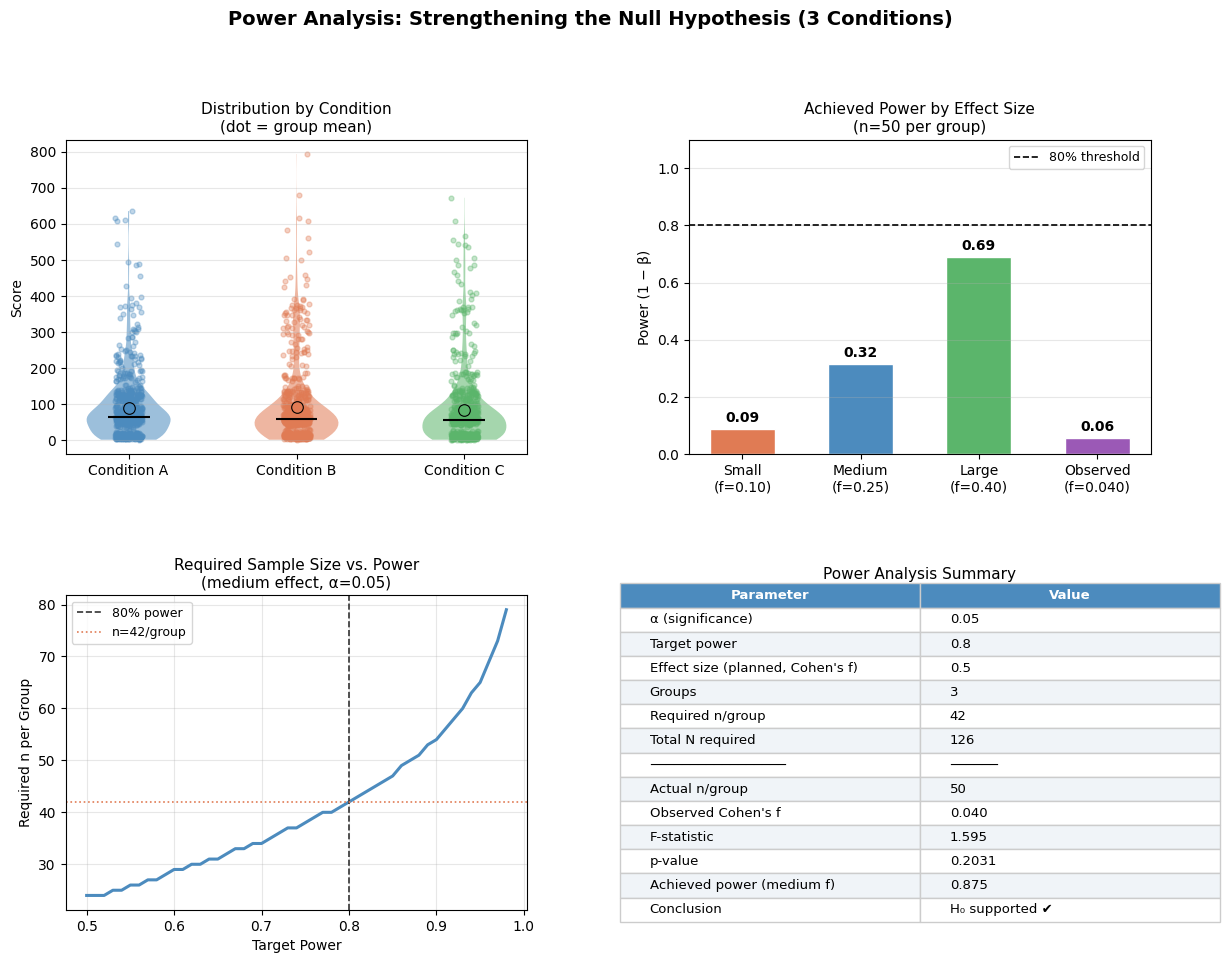

In [76]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

palette = ['#4c8bbe', '#e07b54', '#5bb56b']
labels  = ['Condition A', 'Condition B', 'Condition C']
data_groups = [SHIPWRECKED['euclidean'], SAFECRACKER['euclidean'], BASELINE['euclidean']]

# ── (1) Violin + strip plot ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
parts = ax1.violinplot(data_groups, positions=[1, 2, 3], showmedians=True, showextrema=False)
for i, (pc, color) in enumerate(zip(parts['bodies'], palette)):
    pc.set_facecolor(color)
    pc.set_alpha(0.55)
    jitter = np.random.uniform(-0.08, 0.08, len(data_groups[i]))
    ax1.scatter(np.full(len(data_groups[i]), i + 1) + jitter, data_groups[i],
                color=color, alpha=0.35, s=12)
    ax1.scatter(i + 1, data_groups[i].mean(), color=color, s=70, zorder=5,
                edgecolors='black', linewidths=0.8)
parts['cmedians'].set_color('black')
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(labels)
ax1.set_ylabel('Score')
ax1.set_title('Distribution by Condition\n(dot = group mean)', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# ── (2) Power bar chart ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
effect_labels = ['Small\n(f=0.10)', 'Medium\n(f=0.25)', 'Large\n(f=0.40)', f'Observed\n(f={cohens_f_obs:.3f})']
effect_fs = [0.10, 0.25, 0.40, max(cohens_f_obs, 0.001)]
bar_powers = [
    power_analysis.solve_power(effect_size=f, alpha=ALPHA, nobs=N_PER_GROUP, k_groups=N_GROUPS)
    for f in effect_fs
]
bar_colors = ['#e07b54', '#4c8bbe', '#5bb56b', '#9b59b6']
bars = ax2.bar(effect_labels, bar_powers, color=bar_colors, edgecolor='white', width=0.55)
ax2.axhline(TARGET_POWER, ls='--', color='black', lw=1.2, label='80% threshold')
for bar, pwr in zip(bars, bar_powers):
    ax2.text(bar.get_x() + bar.get_width() / 2, pwr + 0.015, f'{pwr:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Power (1 − β)')
ax2.set_title(f'Achieved Power by Effect Size\n(n={N_PER_GROUP} per group)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# ── (3) Required N curve ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
target_powers = np.arange(0.50, 0.99, 0.01)
required_ns = [
    int(np.ceil(power_analysis.solve_power(
        effect_size=EFFECT_SIZE, alpha=ALPHA, power=p, k_groups=N_GROUPS
    )))
    for p in target_powers
]
ax3.plot(target_powers, required_ns, color='#4c8bbe', lw=2.2)
ax3.axvline(TARGET_POWER, ls='--', color='#333', lw=1.2, label=f'{TARGET_POWER:.0%} power')
ax3.axhline(n_required_ceil, ls=':', color='#e07b54', lw=1.2, label=f'n={n_required_ceil}/group')
ax3.set_xlabel('Target Power')
ax3.set_ylabel('Required n per Group')
ax3.set_title('Required Sample Size vs. Power\n(medium effect, α=0.05)', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ── (4) Summary table ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
table_data = [
    ['Parameter', 'Value'],
    ['α (significance)', f'{ALPHA}'],
    ['Target power', f'{TARGET_POWER}'],
    ["Effect size (planned, Cohen's f)", f'{EFFECT_SIZE}'],
    ['Groups', f'{N_GROUPS}'],
    ['Required n/group', f'{n_required_ceil}'],
    ['Total N required', f'{n_required_ceil * N_GROUPS}'],
    ['─────────────────', '──────'],
    ['Actual n/group', f'{N_PER_GROUP}'],
    ["Observed Cohen's f", f'{cohens_f_obs:.3f}'],
    ['F-statistic', f'{F_stat:.3f}'],
    ['p-value', f'{p_value:.4f}'],
    ['Achieved power (medium f)', f'{power_planned:.3f}'],
    ['Conclusion', 'H₀ supported ✔' if p_value > ALPHA and power_planned >= TARGET_POWER else 'Inconclusive'],
]
tbl = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.3, 1.45)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4c8bbe')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f4f8')
    cell.set_edgecolor('#cccccc')
ax4.set_title('Power Analysis Summary', fontsize=11, pad=12)

plt.suptitle('Power Analysis: Strengthening the Null Hypothesis (3 Conditions)',
             fontsize=14, fontweight='bold', y=1.01)
# plt.savefig('/mnt/user-data/outputs/power_analysis_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Equivalence / TOST Check (Bonus)

An alternative frequentist approach: **Two One-Sided Tests (TOST)** can directly test whether the effect is *smaller than a meaningful threshold*, providing positive evidence for the null.

In [77]:
# Pairwise TOST for each pair of conditions
# Equivalence bounds: ±0.5 SD (half a standard deviation = small practical threshold)
EQUIV_BOUND_SD = 0.5
pooled_sd = np.sqrt(np.mean([np.var(g, ddof=1) for g in data_groups]))
equiv_bound = EQUIV_BOUND_SD * pooled_sd

print(f'Equivalence bound: ±{equiv_bound:.2f} ({EQUIV_BOUND_SD} SD = {EQUIV_BOUND_SD} × {pooled_sd:.2f})')
print()

pairs = [('A', 'B', SHIPWRECKED['euclidean'], SAFECRACKER['euclidean']), ('A', 'C', SHIPWRECKED['euclidean'], BASELINE['euclidean']), ('B', 'C', SAFECRACKER['euclidean'], BASELINE['euclidean'])]

for lbl1, lbl2, g1, g2 in pairs:
    diff = g1.mean() - g2.mean()
    se   = np.sqrt(g1.var(ddof=1)/len(g1) + g2.var(ddof=1)/len(g2))
    df   = len(g1) + len(g2) - 2

    # TOST: two one-sided t-tests
    t_low  = (diff - (-equiv_bound)) / se   # upper bound test
    t_high = (diff -   equiv_bound)  / se   # lower bound test
    p_low  = stats.t.cdf(t_low,  df)
    p_high = 1 - stats.t.cdf(t_high, df)
    p_tost = max(p_low, p_high)             # TOST p = max of the two

    equiv = '✔ Equivalent' if p_tost < ALPHA else '— Not established'
    print(f'  {lbl1} vs {lbl2}: Δ={diff:+.3f}  TOST p={p_tost:.4f}  → {equiv}')

Equivalence bound: ±50.85 (0.5 SD = 0.5 × 101.70)

  A vs B: Δ=-2.742  TOST p=1.0000  → — Not established
  A vs C: Δ=+6.832  TOST p=1.0000  → — Not established
  B vs C: Δ=+9.574  TOST p=1.0000  → — Not established


*References: Cohen, J. (1988). Statistical Power Analysis for the Behavioral Sciences (2nd ed.). Lakens, D. (2017). Equivalence Tests: A Practical Primer. SPPS, 1(1).*